In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_cleaned.xlsx to dataset_cleaned.xlsx


In [2]:
print(uploaded.keys())

dict_keys(['dataset_cleaned.xlsx'])


In [3]:
import pandas as pd
df = pd.read_excel('dataset_cleaned.xlsx', engine='openpyxl')
print(df.shape)
print(df.columns.tolist())

(51290, 24)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [4]:
from sklearn.preprocessing import StandardScaler

customer_df = df.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean',
    'Shipping Cost': 'sum',
    'Order ID': 'count'
}).reset_index()

customer_df.rename(columns={'Order ID': 'Order Count'}, inplace=True)

print(customer_df.shape)
print(customer_df.head())

(1590, 7)
  Customer ID        Sales      Profit  Quantity  Discount  Shipping Cost  \
0    AA-10315  13747.41300   447.69050       145  0.103571        1236.15   
1    AA-10375   5884.19500   677.47740       139  0.166667         903.92   
2    AA-10480  17695.58978  1516.47518       150  0.078474        1633.67   
3    AA-10645  15343.89070  3051.43900       267  0.125945        1752.27   
4      AA-315   2243.25600   535.56600        20  0.225000         215.80   

   Order Count  
0           42  
1           42  
2           38  
3           73  
4            8  


In [5]:
# Select features for clustering
cluster_features = ['Sales', 'Profit', 'Quantity',
                    'Discount', 'Shipping Cost', 'Order Count']

X_cluster = customer_df[cluster_features]

# Scale so no single feature dominates
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Scaling done — shape:", X_scaled.shape)

Scaling done — shape: (1590, 6)


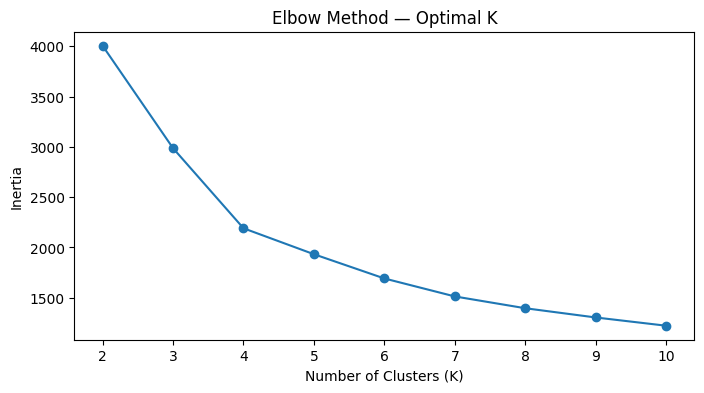

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()

In [8]:
optimal_k = 4

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df['Cluster'] = km_final.fit_predict(X_scaled)

print(customer_df['Cluster'].value_counts())

Cluster
0    532
3    520
2    282
1    256
Name: count, dtype: int64


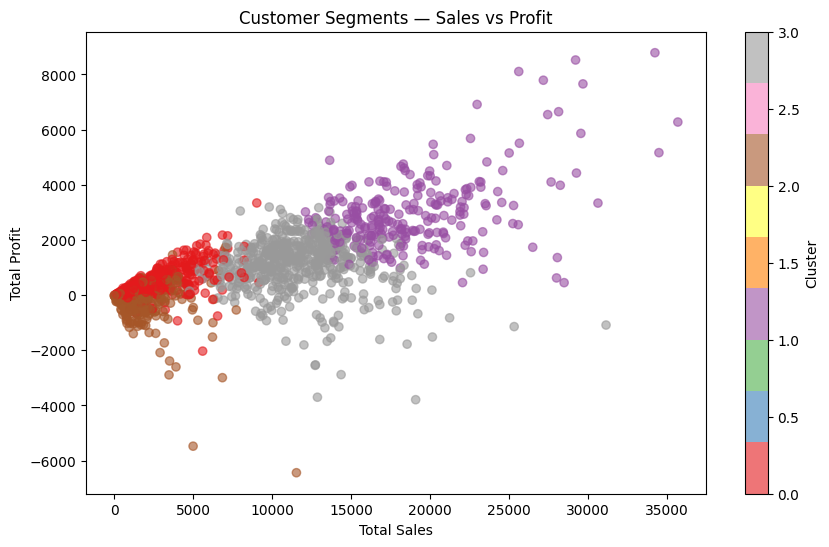

In [9]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    customer_df['Sales'],
    customer_df['Profit'],
    c=customer_df['Cluster'],
    cmap='Set1',
    alpha=0.6
)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments — Sales vs Profit')
plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.show()

In [10]:
cluster_profile = customer_df.groupby('Cluster')[cluster_features].mean().round(2)
print(cluster_profile)

            Sales   Profit  Quantity  Discount  Shipping Cost  Order Count
Cluster                                                                   
0         2390.97   415.63     31.19      0.09         260.86        13.11
1        18780.42  2947.65    234.41      0.12        2021.18        61.60
2         1733.41  -261.87     29.22      0.34         192.40        12.66
3        11680.57  1087.67    179.75      0.14        1235.31        48.03


In [11]:
customer_df.to_csv('customer_segments.csv', index=False)
print("Saved!")

Saved!
